In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#**Telcom Churn Prediction and Analysis**

Predicting Telcom customer retention based on customer features

###**Exploratory Data Analysis**

Let's explore what's going on in this dataset and what these features are about. Here we will:

*   Inspect and clean data
*   Observe univariate trends for each feature and observe multivariate relationships amongst the features
*   Pre-process the data to prepare for modelling phase

#### Shape of the data

In [2]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 7043 rows and 21 columns


#### Inspecting the data

In [3]:
print(f"\n--- Data Type Counts ---")
# Count of columns for each data type
for dtype, count in df.dtypes.value_counts().items():
    print(f"Number of '{dtype}' columns: {count}")

print(f"\n--- Duplicate Counts per Column ---")
# Counts of duplicates in each column
for col in df.columns:
    duplicate_count = df[col].duplicated().sum()
    if duplicate_count > 0:
        print(f"Column '{col}' has {duplicate_count} duplicate values.")
    else:
        print(f"Column '{col}' has no duplicate values.")


--- Data Type Counts ---
Number of 'object' columns: 18
Number of 'int64' columns: 2
Number of 'float64' columns: 1

--- Duplicate Counts per Column ---
Column 'customerID' has no duplicate values.
Column 'gender' has 7041 duplicate values.
Column 'SeniorCitizen' has 7041 duplicate values.
Column 'Partner' has 7041 duplicate values.
Column 'Dependents' has 7041 duplicate values.
Column 'tenure' has 6970 duplicate values.
Column 'PhoneService' has 7041 duplicate values.
Column 'MultipleLines' has 7040 duplicate values.
Column 'InternetService' has 7040 duplicate values.
Column 'OnlineSecurity' has 7040 duplicate values.
Column 'OnlineBackup' has 7040 duplicate values.
Column 'DeviceProtection' has 7040 duplicate values.
Column 'TechSupport' has 7040 duplicate values.
Column 'StreamingTV' has 7040 duplicate values.
Column 'StreamingMovies' has 7040 duplicate values.
Column 'Contract' has 7040 duplicate values.
Column 'PaperlessBilling' has 7041 duplicate values.
Column 'PaymentMethod' h

**Inspection summary:** We see that there are no duplicates in the customerID column (which is our primary key feature in this dataset). This means the dataset is free of duplicates.

There are also 18 object datatypes (which will need to be changed), 2 integer data types, and 1 decimal datatype.

#### Statistical synopsis of the numerical data

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**SeniorCitizen:** Binary values that range from 0, 1 to represent if a customer is a senior or not.

**Tenure:** Number of months the customer has stayed with the company.

- Most ever is 72
- Median customer is paying for 29 months
- 25% of customers are paying for 3/4th of a year

**MonthlyCharges:** The amount charged to each customer monthly.

- Highest monthly bill is $118.75

- Median monthly bill is $70.35

- Minimum monthly bill is $18.25


####**Changing the datatypes of the features**

There are a lot of columns of type 'object' that need to be changed to strings, boolean, or float values. We will inspect the unique values of each and decide which needs to be changed to what.

In [5]:
object_cols = df.select_dtypes(include='object').columns

print(f"Remaining 'object' columns: {list(object_cols)}\n")

for col in object_cols:
    print(f"--- Column: '{col}' ---")
    unique_values = df[col].unique()
    if len(unique_values) <= 20:
        print(f"Unique values ({len(unique_values)}): {unique_values}")
    else:
        print(f"Top 10 unique values ({len(unique_values)} total):\n{df[col].value_counts().head(10)}")
    print("\n")

print("Based on the above, you can decide whether each column is truly categorical (string) or if it needs further numerical conversion.")

Remaining 'object' columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

--- Column: 'customerID' ---
Top 10 unique values (7043 total):
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
7398-LXGYX    1
1035-IPQPU    1
7203-OYKCT    1
1699-HPSBG    1
9837-FWLCH    1
Name: count, dtype: int64


--- Column: 'gender' ---
Unique values (2): ['Female' 'Male']


--- Column: 'Partner' ---
Unique values (2): ['Yes' 'No']


--- Column: 'Dependents' ---
Unique values (2): ['No' 'Yes']


--- Column: 'PhoneService' ---
Unique values (2): ['No' 'Yes']


--- Column: 'MultipleLines' ---
Unique values (3): ['No phone service' 'No' 'Yes']


--- Column: 'InternetService' ---
Unique values (3): ['DSL' 'Fiber optic' 'No']


--- Column

**We can see from here:**

- `Total Charges` needs to be changed to float

- `SeniorCitizen` needs to be changed from integer to boolean

- `PaymentMethod`, `Contract`, and `Internet Service` will be one-hot-encoded to binary values


- `PaperlessBilling`, `StreamingMovies`, `StreamingTV`, `TechSupport`, `DeviceProtection`, `OnlineBackup`, `OnlineSecurity`, `MultipleLines`, `PhoneService`, `Dependents`, `Partner`, and `Gender` will all need to be converted boolean values after having the "No ____ ____" option changed to "FALSE"


In [6]:
# Convert 'TotalCharges' to numeric, handling non-numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print(f"'TotalCharges' converted to dtype: {df['TotalCharges'].dtype}")

'TotalCharges' converted to dtype: float64


In [7]:
# Male = TRUE, Female = FALSE for `Gender`
df['gender'] = df['gender'].apply(lambda x: True if x == 'Male' else False)
print("'gender' column converted to boolean (Male=True, Female=False)")

# Columns to convert to boolean (Yes=True, No/No service=False)
boolean_cols = [
    'PaperlessBilling', 'StreamingMovies', 'StreamingTV', 'TechSupport',
    'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines',
    'PhoneService', 'Dependents', 'Partner', 'Churn'
]

for col in boolean_cols:
    df[col] = df[col].apply(lambda x: True if x == 'Yes' else False)
    print(f"'{col}' column converted to boolean (Yes=True, No/No service=False)")

# Verify types for a few converted columns
print("\nVerifying dtypes for a few boolean columns:")
print(df[['gender', 'PaperlessBilling', 'PhoneService', 'Churn']].dtypes)

'gender' column converted to boolean (Male=True, Female=False)
'PaperlessBilling' column converted to boolean (Yes=True, No/No service=False)
'StreamingMovies' column converted to boolean (Yes=True, No/No service=False)
'StreamingTV' column converted to boolean (Yes=True, No/No service=False)
'TechSupport' column converted to boolean (Yes=True, No/No service=False)
'DeviceProtection' column converted to boolean (Yes=True, No/No service=False)
'OnlineBackup' column converted to boolean (Yes=True, No/No service=False)
'OnlineSecurity' column converted to boolean (Yes=True, No/No service=False)
'MultipleLines' column converted to boolean (Yes=True, No/No service=False)
'PhoneService' column converted to boolean (Yes=True, No/No service=False)
'Dependents' column converted to boolean (Yes=True, No/No service=False)
'Partner' column converted to boolean (Yes=True, No/No service=False)
'Churn' column converted to boolean (Yes=True, No/No service=False)

Verifying dtypes for a few boolean col

In [8]:
# Convert 'SeniorCitizen' to boolean (1=True, 0=False)
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)
print(f"'SeniorCitizen' column converted to dtype: {df['SeniorCitizen'].dtype}")

# Verify the unique values and their type
print("Unique values in 'SeniorCitizen' after conversion:")
print(df['SeniorCitizen'].unique())

'SeniorCitizen' column converted to dtype: bool
Unique values in 'SeniorCitizen' after conversion:
[False  True]


In [9]:
# Perform one-hot encoding for other categorical columns

one_hot_cols = ['PaymentMethod', 'Contract', 'InternetService']

# Use pd.get_dummies to create new columns
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

print("\nOne-hot encoding applied to 'PaymentMethod', 'Contract', 'InternetService'.")
print("Original columns dropped, new dummy variables created.")

# Display the first few rows and info to show changes
print("\nDataFrame head after all transformations:")
display(df.head())
print("\nDataFrame info after all transformations:")
df.info()


One-hot encoding applied to 'PaymentMethod', 'Contract', 'InternetService'.
Original columns dropped, new dummy variables created.

DataFrame head after all transformations:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,False,False,True,False,1,False,False,False,True,...,29.85,29.85,False,False,True,False,False,False,False,False
1,5575-GNVDE,True,False,False,False,34,True,False,True,False,...,56.95,1889.50,False,False,False,True,True,False,False,False
2,3668-QPYBK,True,False,False,False,2,True,False,True,True,...,53.85,108.15,True,False,False,True,False,False,False,False
3,7795-CFOCW,True,False,False,False,45,False,False,True,False,...,42.30,1840.75,False,False,False,False,True,False,False,False
4,9237-HQITU,False,False,False,False,2,True,False,False,False,...,70.70,151.65,True,False,True,False,False,False,True,False



DataFrame info after all transformations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   bool   
 2   SeniorCitizen                          7043 non-null   bool   
 3   Partner                                7043 non-null   bool   
 4   Dependents                             7043 non-null   bool   
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   bool   
 7   MultipleLines                          7043 non-null   bool   
 8   OnlineSecurity                         7043 non-null   bool   
 9   OnlineBackup                           7043 non-null   bool   
 10  DeviceProtection             

### Visualizing Boolean Feature Distributions

Let's visualize the distribution of `True` and `False` values for all the boolean columns we've created or converted. This will give us a quick overview of the proportions within these binary features.

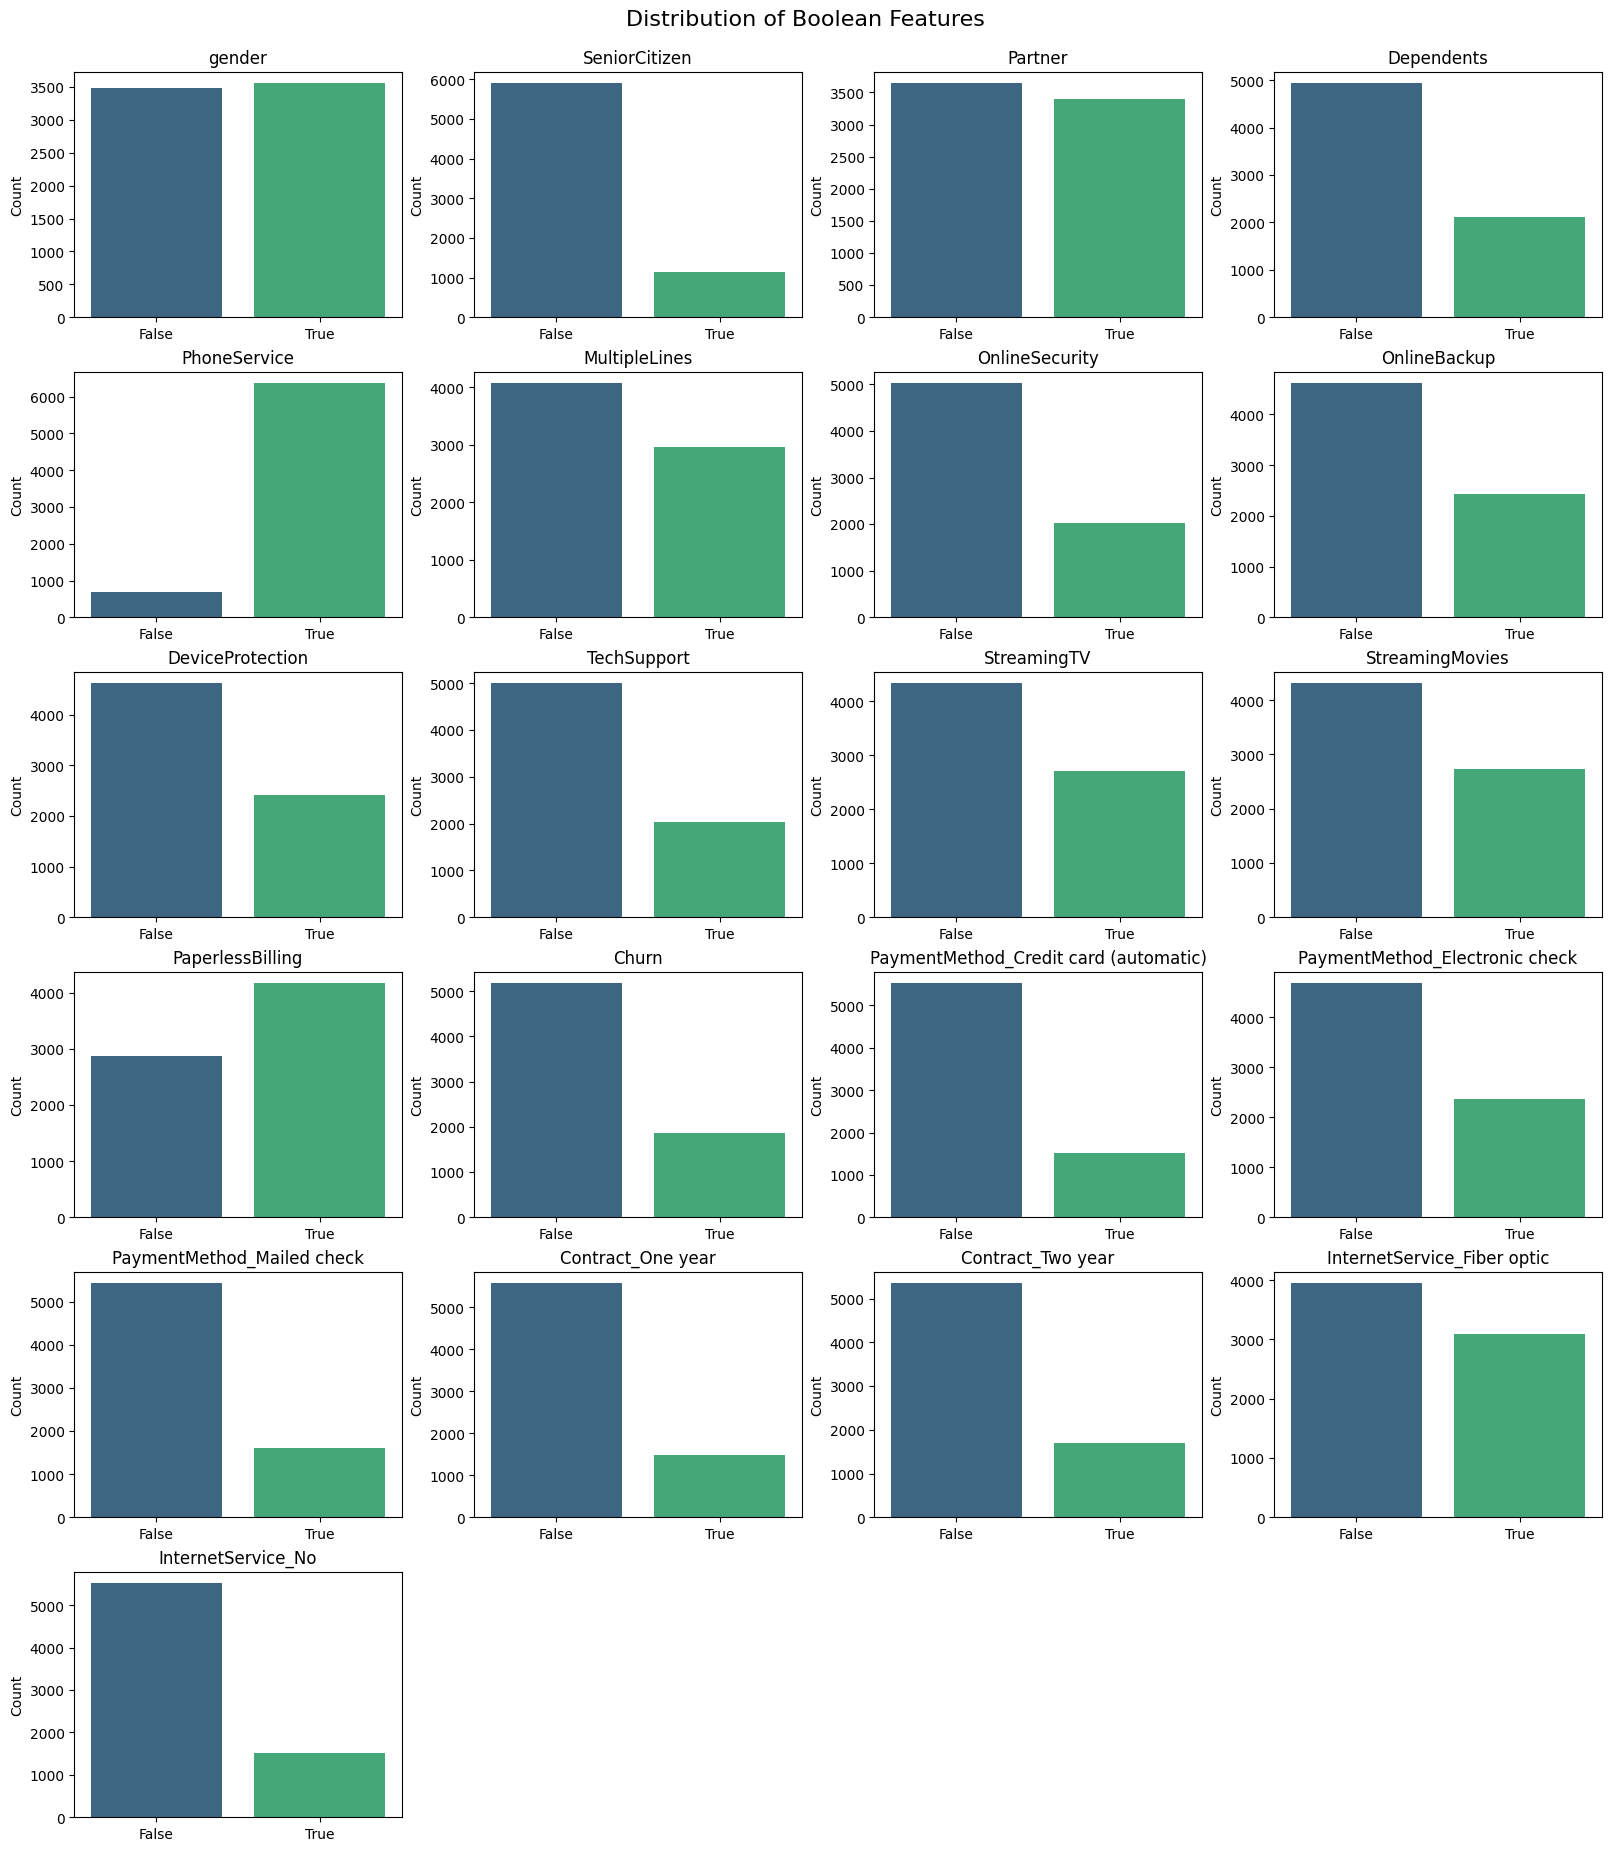

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all boolean columns
boolean_cols = df.select_dtypes(include='bool').columns

num_plots = len(boolean_cols)
num_cols = 4
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(boolean_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('') # Remove x-axis label for cleaner look
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Boolean Features', y=1.02, fontsize=16)
plt.show()

####**Boolean Feature Summarization**

Customers mostly:

- Do paperless billing
- Don't stream movies or TV shows
- Don't have tech support, device protection, online security, or online backup
- Have phone service and doesn't have multiple lines
- Aren't senior citizens, don't have dependents, but are about 50-50 split on having a partner and being male or female

####**Correlation Visual**

Now, let's look at the correlations between our numerical and boolean features. Boolean features will be treated as 0s and 1s for this calculation.

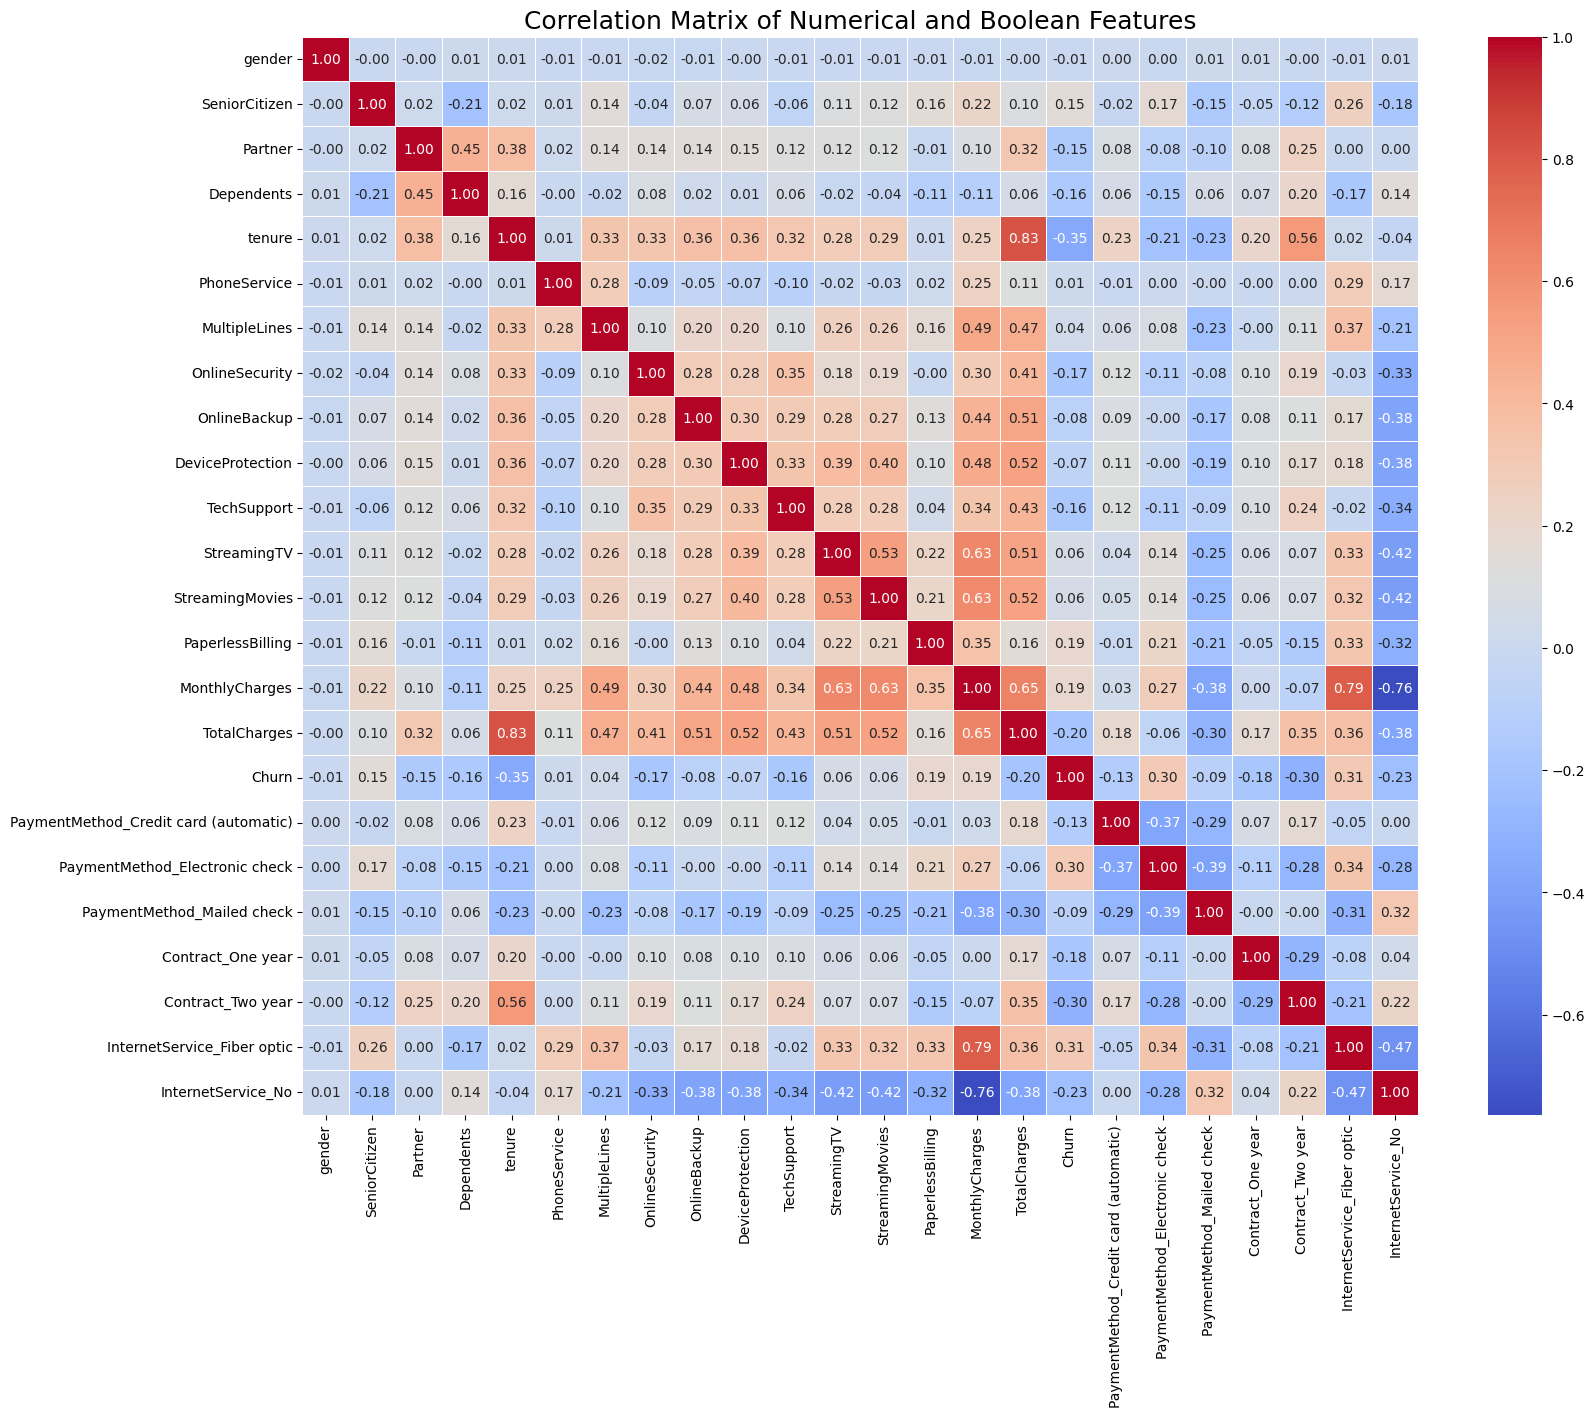

In [11]:
# Select all numerical and boolean columns for correlation
numerical_boolean_cols = df.select_dtypes(include=['number', 'bool']).columns

# Calculate the correlation matrix
corr_matrix = df[numerical_boolean_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(18, 14)) # Adjust figure size for better readability
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical and Boolean Features', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [12]:
import numpy as np

#  Only calculate upper triangle of values in the correlation matrix to exclude self-self corrs
mask = np.triu(corr_matrix)

# Filter for correlations >= 0.40 or <= -0.40 (absolute value)
high_correlation_pairs = {}

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feature1 = corr_matrix.columns[i]
        feature2 = corr_matrix.columns[j]
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) >= 0.40:
            high_correlation_pairs[f'{feature1} & {feature2}'] = correlation

# Sort the pairs by the absolute correlation value in descending order
sorted_high_correlation_pairs = sorted(high_correlation_pairs.items(), key=lambda item: abs(item[1]), reverse=True)

print("Feature pairs with correlation |r| >= 0.40:")
if not sorted_high_correlation_pairs:
    print("No pairs found with correlation |r| >= 0.40.")
else:
    for pair, corr_value in sorted_high_correlation_pairs:
        print(f"- {pair}: {corr_value:.2f}")

Feature pairs with correlation |r| >= 0.40:
- tenure & TotalCharges: 0.83
- MonthlyCharges & InternetService_Fiber optic: 0.79
- MonthlyCharges & InternetService_No: -0.76
- MonthlyCharges & TotalCharges: 0.65
- StreamingTV & MonthlyCharges: 0.63
- StreamingMovies & MonthlyCharges: 0.63
- tenure & Contract_Two year: 0.56
- StreamingTV & StreamingMovies: 0.53
- DeviceProtection & TotalCharges: 0.52
- StreamingMovies & TotalCharges: 0.52
- StreamingTV & TotalCharges: 0.51
- OnlineBackup & TotalCharges: 0.51
- MultipleLines & MonthlyCharges: 0.49
- DeviceProtection & MonthlyCharges: 0.48
- MultipleLines & TotalCharges: 0.47
- InternetService_Fiber optic & InternetService_No: -0.47
- Partner & Dependents: 0.45
- OnlineBackup & MonthlyCharges: 0.44
- TechSupport & TotalCharges: 0.43
- StreamingMovies & InternetService_No: -0.42
- StreamingTV & InternetService_No: -0.42
- OnlineSecurity & TotalCharges: 0.41
- DeviceProtection & StreamingMovies: 0.40


Long list of variable pairs that are well correlated together. The highest amongst the list being:

- `Tenure` and `TotalCharges`
- `MonthlyCharges` with what type of internet service a customer has
- `MonthlyCharges` and `TotalCharges`
- `MonthlyCharges` and whether or not a customer streams TV shows or movies

Amongst more pairs...

In [13]:
# Get correlations with 'Churn'
churn_correlations = corr_matrix['Churn'].drop('Churn') # Drop self-correlation

# Sort correlations by absolute value in descending order
sorted_churn_correlations = churn_correlations.abs().sort_values(ascending=False)

print("Features most correlated with 'Churn':")
if not sorted_churn_correlations.empty:
    for feature, abs_corr in sorted_churn_correlations.items():
        # Get the actual correlation value (not just absolute)
        actual_corr = churn_correlations[feature]
        print(f"- {feature}: {actual_corr:.2f} (Absolute: {abs_corr:.2f})")
else:
    print("No correlations found with 'Churn'.")

Features most correlated with 'Churn':
- tenure: -0.35 (Absolute: 0.35)
- InternetService_Fiber optic: 0.31 (Absolute: 0.31)
- Contract_Two year: -0.30 (Absolute: 0.30)
- PaymentMethod_Electronic check: 0.30 (Absolute: 0.30)
- InternetService_No: -0.23 (Absolute: 0.23)
- TotalCharges: -0.20 (Absolute: 0.20)
- MonthlyCharges: 0.19 (Absolute: 0.19)
- PaperlessBilling: 0.19 (Absolute: 0.19)
- Contract_One year: -0.18 (Absolute: 0.18)
- OnlineSecurity: -0.17 (Absolute: 0.17)
- TechSupport: -0.16 (Absolute: 0.16)
- Dependents: -0.16 (Absolute: 0.16)
- SeniorCitizen: 0.15 (Absolute: 0.15)
- Partner: -0.15 (Absolute: 0.15)
- PaymentMethod_Credit card (automatic): -0.13 (Absolute: 0.13)
- PaymentMethod_Mailed check: -0.09 (Absolute: 0.09)
- OnlineBackup: -0.08 (Absolute: 0.08)
- DeviceProtection: -0.07 (Absolute: 0.07)
- StreamingTV: 0.06 (Absolute: 0.06)
- StreamingMovies: 0.06 (Absolute: 0.06)
- MultipleLines: 0.04 (Absolute: 0.04)
- PhoneService: 0.01 (Absolute: 0.01)
- gender: -0.01 (Absol

####**Features that are well correlated with `Churn`**

- `Tenure`
- `InternetService_Fiber Optic`
- `Contract_Two year`
- `PaymentMethod_Eletronic check`
- `InternetService_No`
- `TotalCharges`


###**Modelling Phase: How can we predict Churn**

####**Data Splitting**

First, we need to separate our features (X) from our target variable (Y, which is `Churn`). Then, we'll split the data into training and testing sets to evaluate our model's performance on unseen data. We'll use `customerID` as an identifier, but it's not a feature for the model.

In [14]:
from sklearn.model_selection import train_test_split

# Drop customerID
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print('\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))
print('\nChurn distribution in test set:')
print(y_test.value_counts(normalize=True))

X_train shape: (5634, 23)
X_test shape: (1409, 23)
y_train shape: (5634,)
y_test shape: (1409,)

Churn distribution in training set:
Churn
False    0.734647
True     0.265353
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
False    0.734564
True     0.265436
Name: proportion, dtype: float64


###**Preprocessing (Scaling)**

We'll use `StandardScaler` to transform our continuous numerical features. Boolean features, which are already 0s and 1s, don't need additional scaling, so we'll pass them through without modification using a `ColumnTransformer`.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numerical columns are 'tenure', 'MonthlyCharges', 'TotalCharges'
# All other columns (excluding 'customerID' and 'Churn') are boolean/one-hot encoded

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
boolean_cols = X_train.select_dtypes(include='bool').columns.tolist()

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('bool', 'passthrough', boolean_cols)
    ],
    remainder='drop'
)

# Apply preprocessing to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed. Shapes of processed data:")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Preprocessing completed. Shapes of processed data:
X_train_processed shape: (5634, 23)
X_test_processed shape: (1409, 23)


####**Model Training, Tuning, and Evaluation**

We'll now train a few different classification models, tune their hyperparameters using 5-fold cross-validation, and then evaluate their performance on the test set. Our focus will be on the 'Churn == Yes' class, so we'll pay close attention to metrics like recall and F1-score for this class, as well as the overall ROC AUC score.

#### Model 1: Logistic Regression


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Define the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear',
                             random_state=123,
                             class_weight='balanced')

# Define parameter grid for GridSearchCV
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Using 'roc_auc' as the scoring metric for tuning, as it's robust to class imbalance
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the processed training data
grid_search_lr.fit(X_train_processed, y_train)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best ROC AUC score for Logistic Regression (CV):", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Logistic Regression: {'C': 100}
Best ROC AUC score for Logistic Regression (CV): 0.845620714815175


##### Evaluation of Logistic Regression Model


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



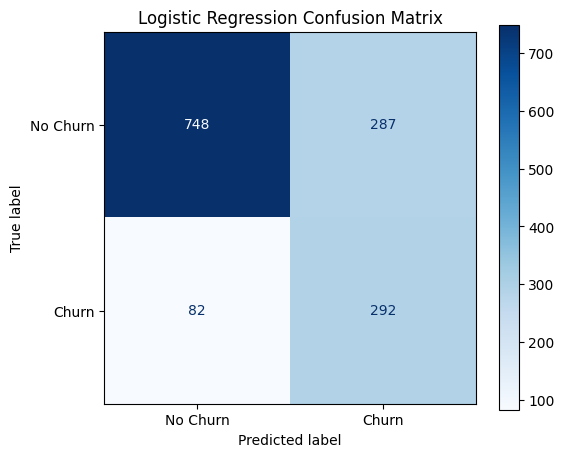

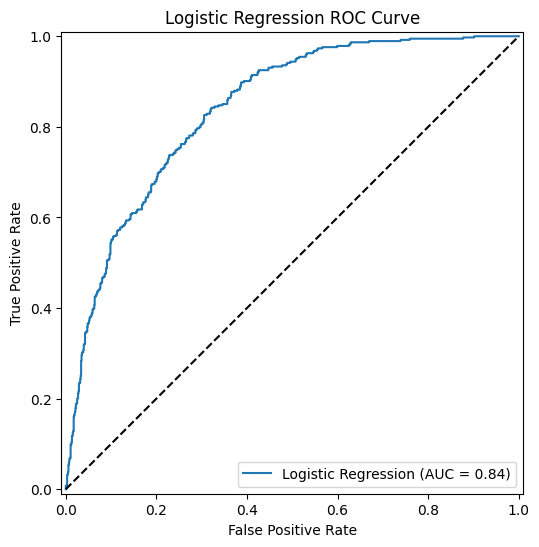

Logistic Regression Test ROC AUC: 0.84


In [17]:
# Make predictions on the test set
y_pred_lr = best_lr_model.predict(X_test_processed)
# Probability of positive class (Churn = Yes)
y_prob_lr = best_lr_model.predict_proba(X_test_processed)[:, 1]

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig_cm_lr, ax_cm_lr = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', ax=ax_cm_lr)
ax_cm_lr.set_title('Logistic Regression Confusion Matrix')
plt.show()

# ROC AUC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fig_roc_lr, ax_roc_lr = plt.subplots(figsize=(7, 6))
RocCurveDisplay(fpr=fpr_lr, tpr=tpr_lr, roc_auc=roc_auc_lr, estimator_name='Logistic Regression').plot(ax=ax_roc_lr)
ax_roc_lr.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc_lr.set_title('Logistic Regression ROC Curve')
plt.show()

print(f"Logistic Regression Test ROC AUC: {roc_auc_lr:.2f}")

/tmp/ipykernel_4422/2058327705.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_lr, palette='magma', ax=ax_importance_lr)


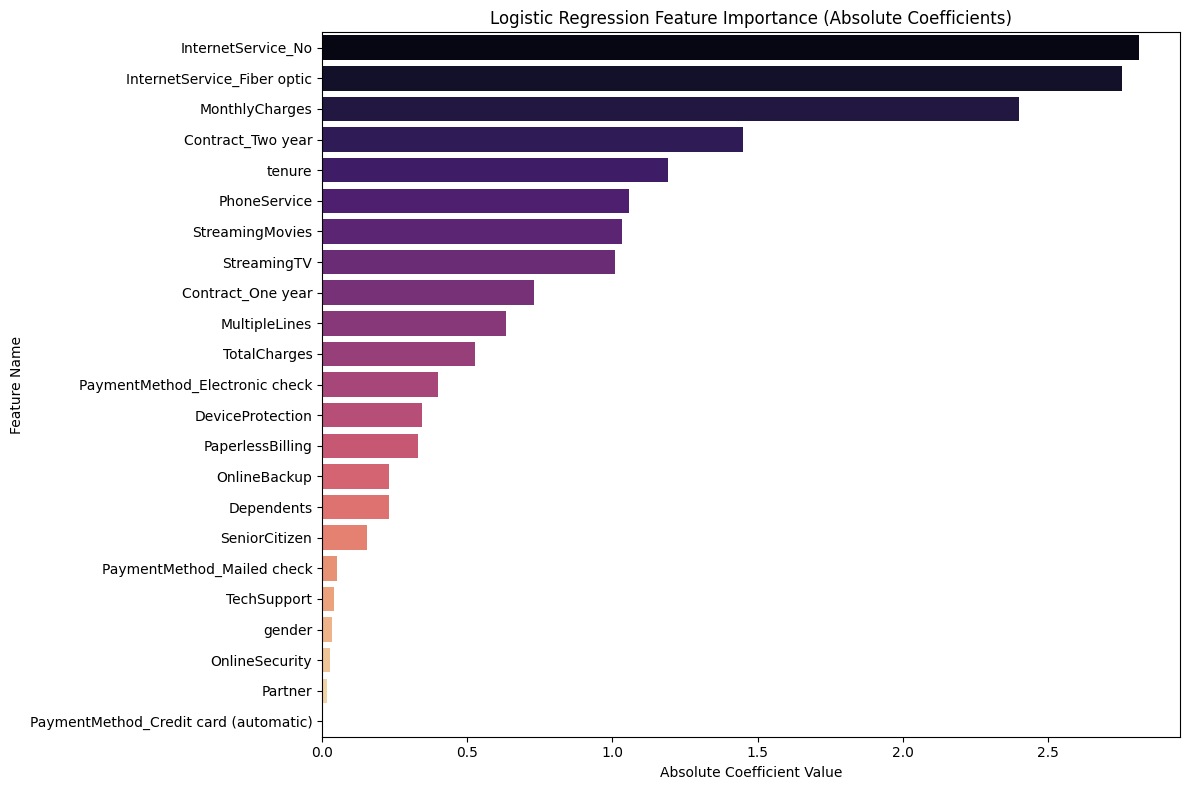

In [24]:
# Get coefficients from the best Logistic Regression model
# The coefficients represent feature importance in linear models
coefficients_lr = best_lr_model.coef_[0]

# Create a DataFrame for better visualization (using absolute values for importance)
importance_df_lr = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': np.abs(coefficients_lr)
})

# Sort by importance
importance_df_lr = importance_df_lr.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
fig_importance_lr, ax_importance_lr = plt.subplots(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_lr, palette='magma', ax=ax_importance_lr)
ax_importance_lr.set_title('Logistic Regression Feature Importance (Absolute Coefficients)')
ax_importance_lr.set_xlabel('Absolute Coefficient Value')
ax_importance_lr.set_ylabel('Feature Name')
plt.tight_layout()
plt.show()

#### Model 2: Random Forest Classifier



In [18]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' helps address class imbalance, similar to Logistic Regression
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

# Setup GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the processed training data
grid_search_rf.fit(X_train_processed, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best ROC AUC score for Random Forest (CV):", grid_search_rf.best_score_)

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best ROC AUC score for Random Forest (CV): 0.8461747685785536


##### Evaluation of Random Forest Model


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.92      0.71      0.80      1035
       Churn       0.51      0.82      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



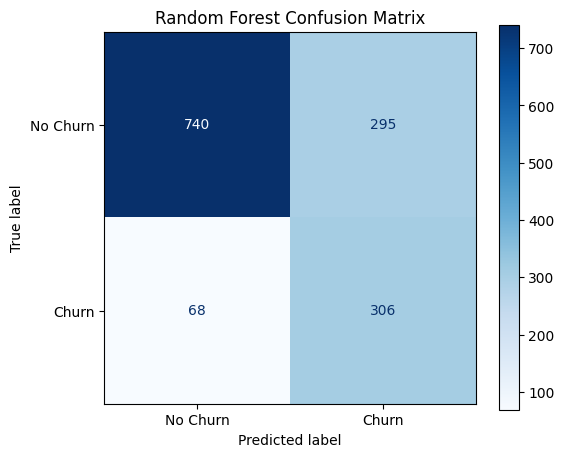

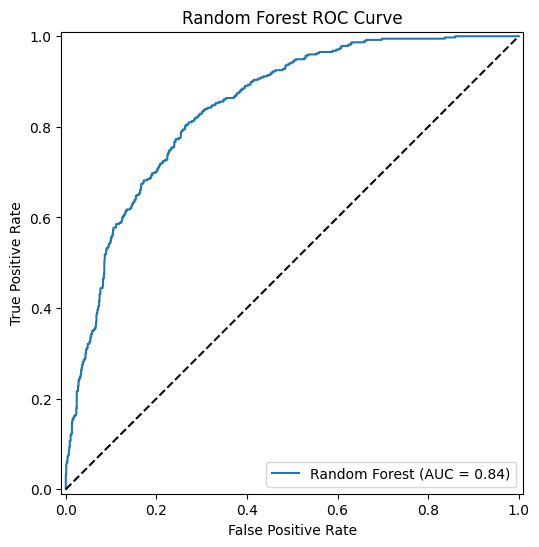

Random Forest Test ROC AUC: 0.84


In [19]:
# Make predictions on the test set
y_pred_rf = best_rf_model.predict(X_test_processed)
# Probability of positive class (Churn = Yes)
y_prob_rf = best_rf_model.predict_proba(X_test_processed)[:, 1]

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig_cm_rf, ax_cm_rf = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', ax=ax_cm_rf)
ax_cm_rf.set_title('Random Forest Confusion Matrix')
plt.show()

# ROC AUC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fig_roc_rf, ax_roc_rf = plt.subplots(figsize=(7, 6))
RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf, roc_auc=roc_auc_rf, estimator_name='Random Forest').plot(ax=ax_roc_rf)
ax_roc_rf.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc_rf.set_title('Random Forest ROC Curve')
plt.show()

print(f"Random Forest Test ROC AUC: {roc_auc_rf:.2f}")

##### Feature Importance for Random Forest Model

/tmp/ipykernel_4422/3217883244.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax_importance)


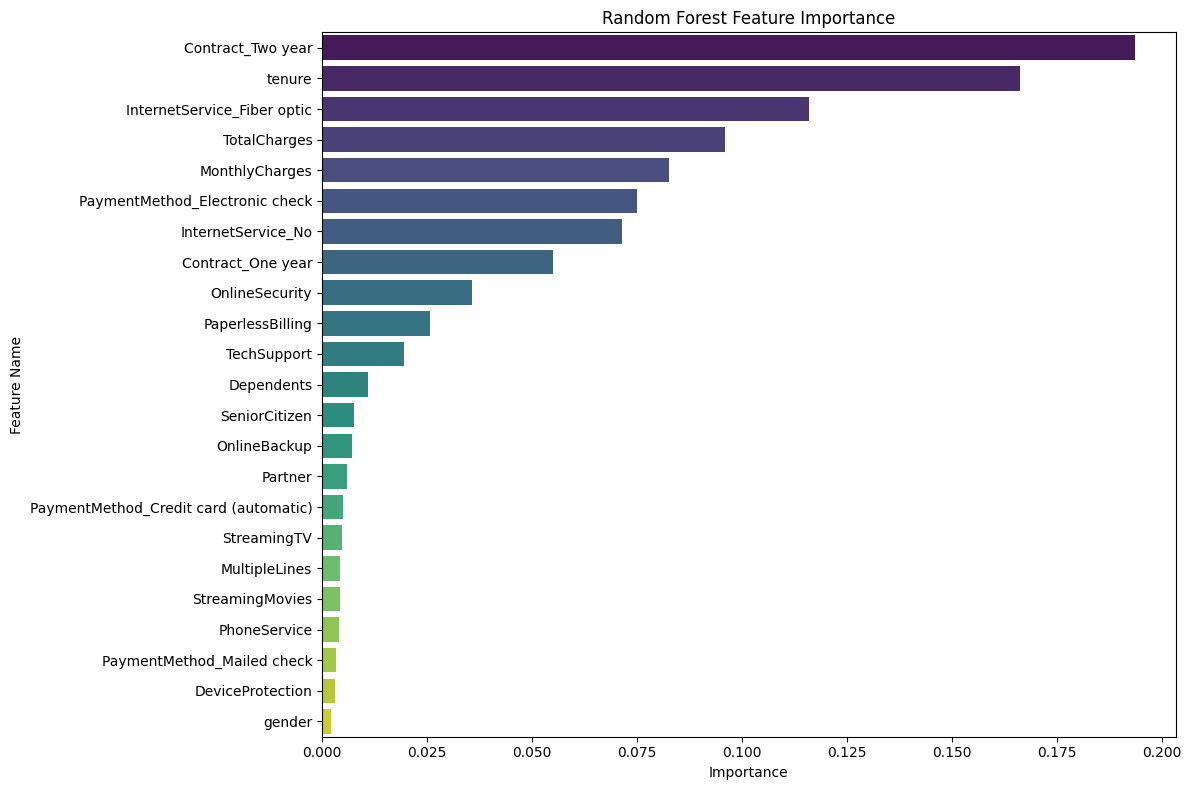

In [23]:
# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

#Get feature names from the preprocessor's transformers
# The preprocessor has two transformers: 'num' (StandardScaler) and 'bool' (passthrough)

# Get numerical & Boolean feature names
num_feature_names = preprocessor.named_transformers_['num'].get_feature_names_out(numerical_cols)
bool_feature_names = preprocessor.named_transformers_['bool'].get_feature_names_out(boolean_cols)

# Combine all feature names in the correct order
all_feature_names = list(num_feature_names) + list(bool_feature_names)

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
fig_importance, ax_importance = plt.subplots(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax_importance)
ax_importance.set_title('Random Forest Feature Importance')
ax_importance.set_xlabel('Importance')
ax_importance.set_ylabel('Feature Name')
plt.tight_layout()
plt.show()

#### Model 3: Gradient Boosting Classifier

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

#Define the Gradient Boosting Classifier model
gbc_clf = GradientBoostingClassifier(random_state=42)

# Define parameter grid for GridSearchCV
param_grid_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Setup GridSearchCV for Gradient Boosting
grid_search_gbc = GridSearchCV(
    estimator=gbc_clf,
    param_grid=param_grid_gbc,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the processed training data
grid_search_gbc.fit(X_train_processed, y_train)

print("Best parameters for Gradient Boosting Classifier:", grid_search_gbc.best_params_)
print("Best ROC AUC score for Gradient Boosting Classifier (CV):", grid_search_gbc.best_score_)

#Get the best model
best_gbc_model = grid_search_gbc.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Gradient Boosting Classifier: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best ROC AUC score for Gradient Boosting Classifier (CV): 0.848385771707935


##### Evaluation of Gradient Boosting Classifier Model


--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



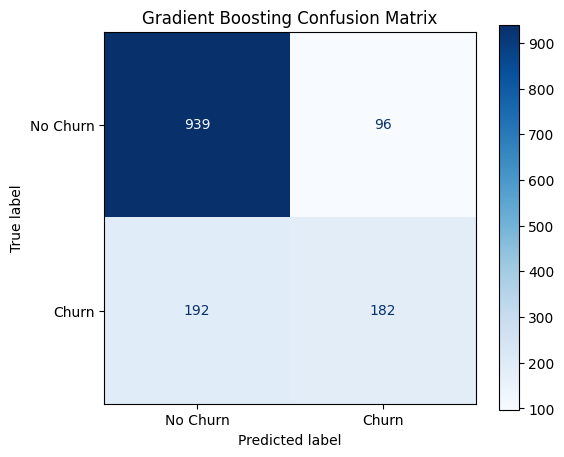

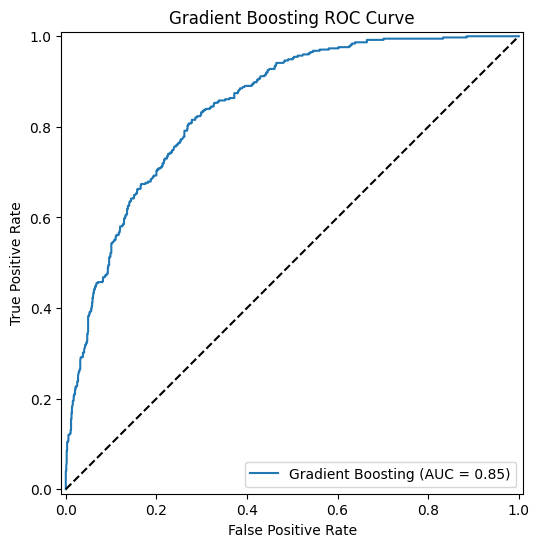

Gradient Boosting Test ROC AUC: 0.85


In [22]:
# Make predictions on the test set
y_pred_gbc = best_gbc_model.predict(X_test_processed)
# Probability of positive class (Churn = Yes)
y_prob_gbc = best_gbc_model.predict_proba(X_test_processed)[:, 1]

print("\n--- Gradient Boosting Classification Report ---")
print(classification_report(y_test, y_pred_gbc, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_gbc = confusion_matrix(y_test, y_pred_gbc)
fig_cm_gbc, ax_cm_gbc = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_gbc, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', ax=ax_cm_gbc)
ax_cm_gbc.set_title('Gradient Boosting Confusion Matrix')
plt.show()

# ROC AUC Curve
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_prob_gbc)
roc_auc_gbc = auc(fpr_gbc, tpr_gbc)

fig_roc_gbc, ax_roc_gbc = plt.subplots(figsize=(7, 6))
RocCurveDisplay(fpr=fpr_gbc, tpr=tpr_gbc, roc_auc=roc_auc_gbc, estimator_name='Gradient Boosting').plot(ax=ax_roc_gbc)
ax_roc_gbc.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc_gbc.set_title('Gradient Boosting ROC Curve')
plt.show()

print(f"Gradient Boosting Test ROC AUC: {roc_auc_gbc:.2f}")

##### Feature Importance for Gradient Boosting Classifier Model

/tmp/ipykernel_4422/3976206996.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_gbc, palette='cubehelix', ax=ax_importance_gbc)


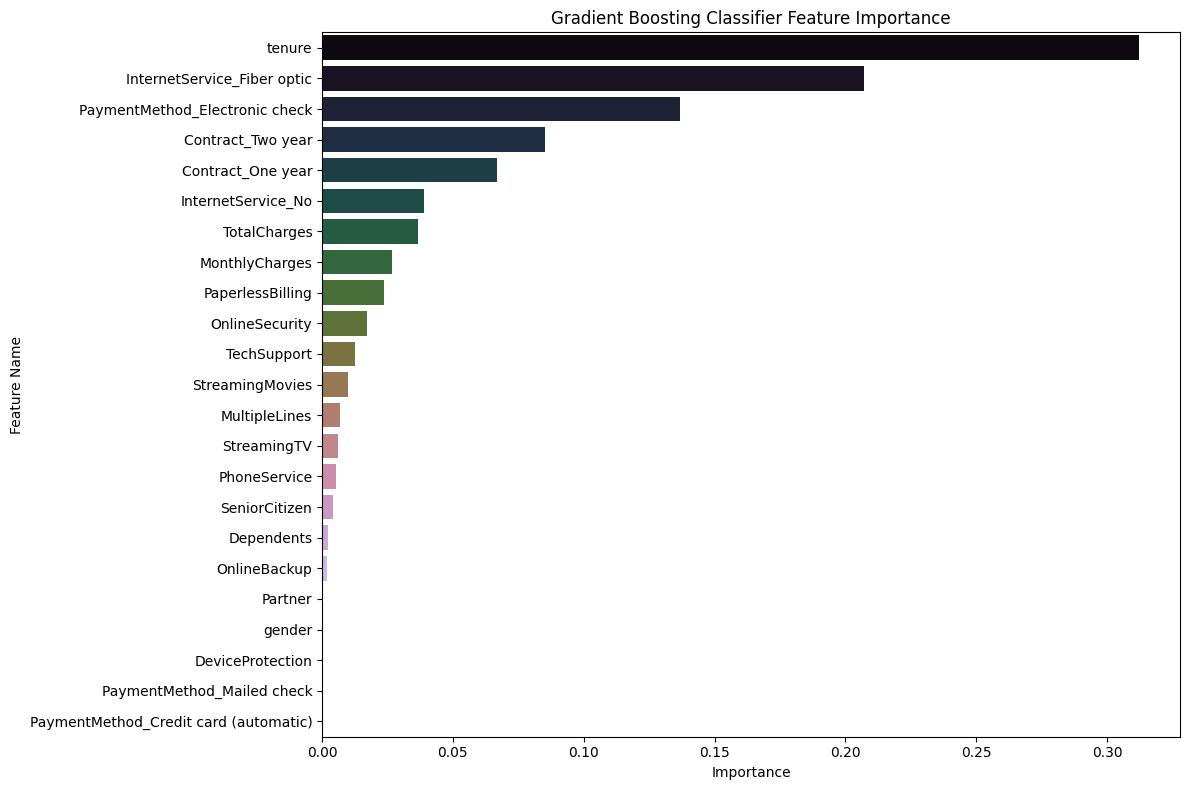

In [25]:
# Get feature importances from the best Gradient Boosting Classifier model
feature_importances_gbc = best_gbc_model.feature_importances_

# Create a DataFrame for better visualization
importance_df_gbc = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances_gbc
})

# Sort by importance
importance_df_gbc = importance_df_gbc.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
fig_importance_gbc, ax_importance_gbc = plt.subplots(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_gbc, palette='cubehelix', ax=ax_importance_gbc)
ax_importance_gbc.set_title('Gradient Boosting Classifier Feature Importance')
ax_importance_gbc.set_xlabel('Importance')
ax_importance_gbc.set_ylabel('Feature Name')
plt.tight_layout()
plt.show()

###**Refined Random Forest Classifier - Post Feature Selection**



Based on the feature importance analysis of the initial Random Forest model, we will identify and remove features with low importance.

In [27]:
# Define a threshold for feature importance (e.g., remove features with importance < 0.02)
importance_threshold = 0.02

# Get features to keep based on the importance_df from the previous RF model
features_to_keep = importance_df[importance_df['Importance'] >= importance_threshold]['Feature'].tolist()

print(f"Original number of features: {len(all_feature_names)}")
print(f"Number of features after selection (importance >= {importance_threshold}): {len(features_to_keep)}")
print(f"Features removed: {set(all_feature_names) - set(features_to_keep)}")

# Filter X_train and X_test to include only selected features
X_train_filtered = X_train[features_to_keep]
X_test_filtered = X_test[features_to_keep]

# Ensure these lists are based on `features_to_keep` and maintain correct types
filtered_numerical_cols = [col for col in numerical_cols if col in features_to_keep]
filtered_boolean_cols = [col for col in boolean_cols if col in features_to_keep]

# Create a new preprocessor for the filtered features
preprocessor_filtered = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), filtered_numerical_cols),
        ('bool', 'passthrough', filtered_boolean_cols)
    ],
    remainder='drop'
)

# Apply preprocessing to the filtered data
X_train_processed_filtered = preprocessor_filtered.fit_transform(X_train_filtered)
X_test_processed_filtered = preprocessor_filtered.transform(X_test_filtered)

print("\nPreprocessing completed for filtered data. Shapes:")
print(f"X_train_processed_filtered shape: {X_train_processed_filtered.shape}")
print(f"X_test_processed_filtered shape: {X_test_processed_filtered.shape}")

Original number of features: 23
Number of features after selection (importance >= 0.02): 10
Features removed: {'PaymentMethod_Credit card (automatic)', 'OnlineBackup', 'Dependents', 'TechSupport', 'Partner', 'MultipleLines', 'gender', 'PaymentMethod_Mailed check', 'SeniorCitizen', 'DeviceProtection', 'StreamingTV', 'PhoneService', 'StreamingMovies'}

Preprocessing completed for filtered data. Shapes:
X_train_processed_filtered shape: (5634, 10)
X_test_processed_filtered shape: (1409, 10)


##### Training the Refined Random Forest Model

In [28]:
# Use the best parameters found earlier for the Random Forest model
# (or define a new param_grid if further tuning is desired)
refined_rf_clf = RandomForestClassifier(
    n_estimators=best_rf_model.n_estimators,
    max_depth=best_rf_model.max_depth,
    min_samples_split=best_rf_model.min_samples_split,
    random_state=42,
    class_weight='balanced'
)

# Fit the refined model to the processed filtered training data
refined_rf_clf.fit(X_train_processed_filtered, y_train)

print("Refined Random Forest model trained successfully!")

Refined Random Forest model trained successfully!


##### Evaluation of Refined Random Forest Model


--- Refined Random Forest Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409



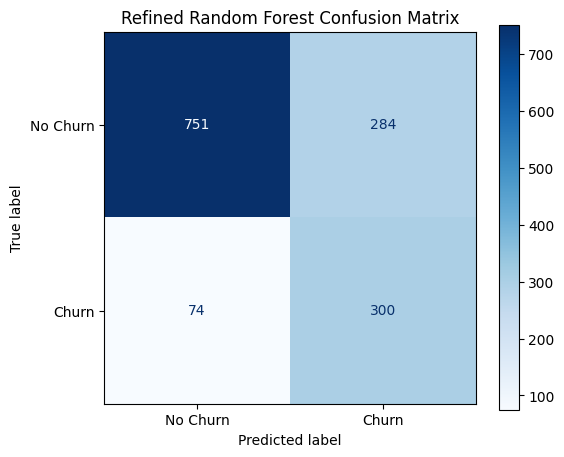

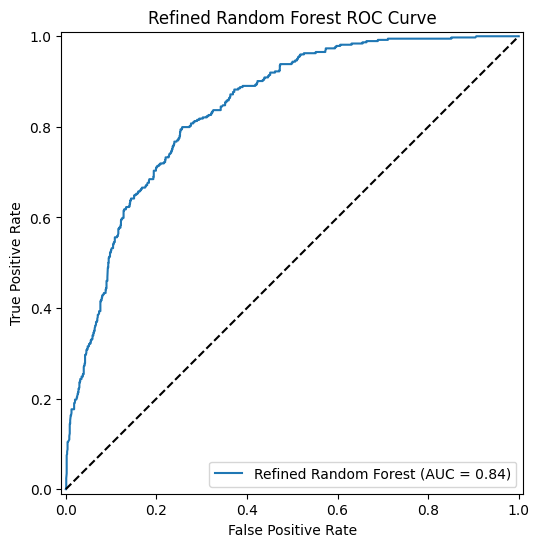

Refined Random Forest Test ROC AUC: 0.84


In [29]:
# Make predictions on the test set
y_pred_refined_rf = refined_rf_clf.predict(X_test_processed_filtered)
# Probability of positive class (Churn = Yes)
y_prob_refined_rf = refined_rf_clf.predict_proba(X_test_processed_filtered)[:, 1]

print("\n--- Refined Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_refined_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_refined_rf = confusion_matrix(y_test, y_pred_refined_rf)
fig_cm_refined_rf, ax_cm_refined_rf = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_refined_rf, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', ax=ax_cm_refined_rf)
ax_cm_refined_rf.set_title('Refined Random Forest Confusion Matrix')
plt.show()

# ROC AUC Curve
fpr_refined_rf, tpr_refined_rf, _ = roc_curve(y_test, y_prob_refined_rf)
roc_auc_refined_rf = auc(fpr_refined_rf, tpr_refined_rf)

fig_roc_refined_rf, ax_roc_refined_rf = plt.subplots(figsize=(7, 6))
RocCurveDisplay(fpr=fpr_refined_rf, tpr=tpr_refined_rf, roc_auc=roc_auc_refined_rf, estimator_name='Refined Random Forest').plot(ax=ax_roc_refined_rf)
ax_roc_refined_rf.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc_refined_rf.set_title('Refined Random Forest ROC Curve')
plt.show()

print(f"Refined Random Forest Test ROC AUC: {roc_auc_refined_rf:.2f}")

###**Result From Refined RF Model**

Not much improvement, if any at all, over the original model with all of the features.

Ultimately, we need higher precision scores as the precisions from all models collectively are in that 0.50-0.51 range; the recall has been solid but higher precision means the model is just not labelling "yes" for the sake of doing so.

### Threshold Optimization for Refined Random Forest Model

To improve precision without losing too much recall, it's time to analyze the Precision-Recall curve for the `Refined Random Forest` model.

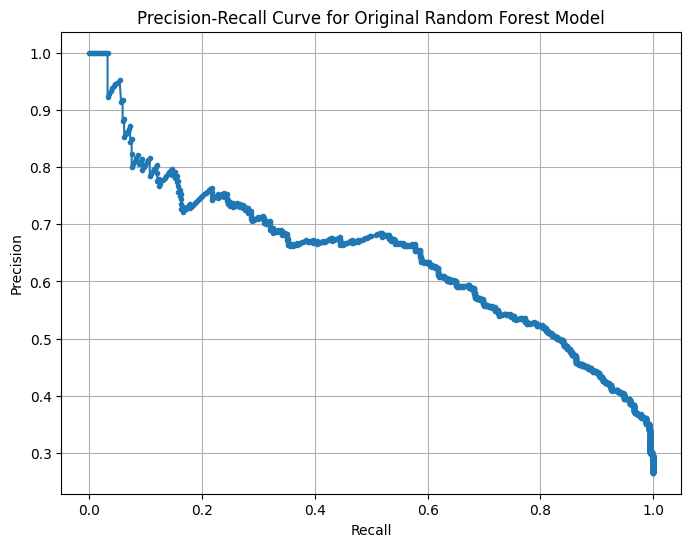

Selected Optimal Threshold for Original RF: 0.62

--- Original Random Forest Classification Report (Tuned Threshold) ---
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.86      1035
       Churn       0.60      0.65      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



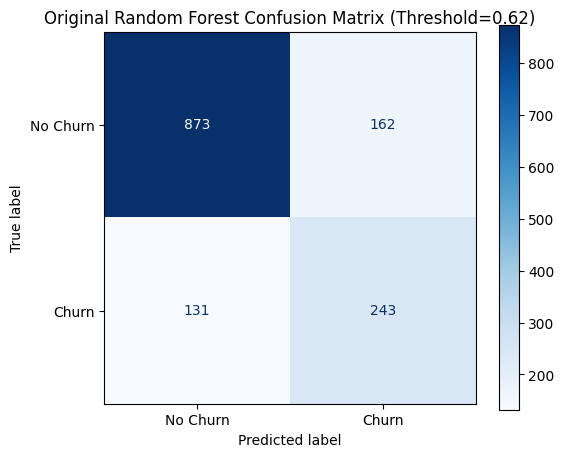

In [32]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate precision-recall pairs for different probability thresholds using probabilities from the ORIGINAL RF model
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)

# Plotting the Precision-Recall curve for the original RF model
fig_pr_rf, ax_pr_rf = plt.subplots(figsize=(8, 6))
ax_pr_rf.plot(recall_rf, precision_rf, marker='.')
ax_pr_rf.set_xlabel('Recall')
ax_pr_rf.set_ylabel('Precision')
ax_pr_rf.set_title('Precision-Recall Curve for Original Random Forest Model')
ax_pr_rf.grid(True)
plt.show()

# Find an optimal threshold for the original RF model
optimal_threshold_rf = 0.45

# Target: precision >= 0.60 and recall > 0.60 for the 'Churn' class
for i in range(len(thresholds_rf)):
    if precision_rf[i] >= 0.60 and recall_rf[i] > 0.60:
        optimal_threshold_rf = thresholds_rf[i]
        break

print(f"Selected Optimal Threshold for Original RF: {optimal_threshold_rf:.2f}")

# Re-evaluate the original RF model with the new tuned threshold
y_pred_tuned_original_rf = (y_prob_rf >= optimal_threshold_rf).astype(bool)

print("\n--- Original Random Forest Classification Report (Tuned Threshold) ---")
print(classification_report(y_test, y_pred_tuned_original_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix with tuned threshold for original RF
cm_tuned_original_rf = confusion_matrix(y_test, y_pred_tuned_original_rf)
fig_cm_tuned_original_rf, ax_cm_tuned_original_rf = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_tuned_original_rf, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', ax=ax_cm_tuned_original_rf)
ax_cm_tuned_original_rf.set_title(f'Original Random Forest Confusion Matrix (Threshold={optimal_threshold_rf:.2f})')
plt.show()

## Summary and Conclusion


### 1. Data Loading and Initial Inspection

*   The `Telcom Customer Churn` dataset was loaded into a pandas DataFrame. Its shape was confirmed to be 7043 rows and 21 columns.
*   Initial inspection revealed a mix of object, integer, and float data types. Importantly, `customerID` was confirmed to have no duplicate values, serving as a reliable primary key.

### 2. Data Preprocessing and Cleaning

*   The `TotalCharges` column was successfully converted to `float` and non-numeric values were handled by filling with `0`.
*   Several object columns (e.g., `gender`, `PaperlessBilling`, `Churn`, etc.) were converted to boolean types based on 'Yes'/'No' or 'Male'/'Female' mappings.
*   `SeniorCitizen` was also converted from integer to boolean.
*   Categorical features (`PaymentMethod`, `Contract`, `InternetService`) were one-hot encoded to create binary representation, preparing them for modeling.

### 3. Exploratory Data Analysis (EDA)

*   **Boolean Feature Distributions:** Visualizations of boolean features provided insights into customer demographics and service usage patterns (e.g., most customers do paperless billing, fewer use streaming services).
*   **Correlation Analysis:** A heatmap and a list of highly correlated feature pairs (`|r| >= 0.40`) were generated. Key findings included strong correlations between `tenure` and `TotalCharges`, and `MonthlyCharges` with `InternetService_Fiber optic`.
*   **Churn Correlations:** Features most correlated with `Churn` were identified, with `tenure`, `InternetService_Fiber optic`, `Contract_Two year`, and `PaymentMethod_Electronic check` showing the strongest relationships.

### 4. Model Building and Evaluation

*   **Data Splitting:** The data was split into features (`X`) and target (`Y`, `Churn`), then further divided into training and testing sets (80/20 split) using stratification to maintain class balance.
*   **Preprocessing Pipeline:** A ColumnTransformer with StandardScaler for numerical features and passthrough for boolean/one-hot encoded features was used to prepare data for modeling.
*   **Three models were trained and evaluated:**
    *   **Logistic Regression:** Achieved a test ROC AUC of 0.84, with Churn Recall of 0.7` and Churn Precision of 0.50.
    *   **Random Forest Classifier (Original):** Achieved a test ROC AUC of 0.84, with Churn Recall of 0.82 and Churn Precision of 0.51.
    *   **Gradient Boosting Classifier:** Achieved a test ROC AUC of 0.85, with Churn Recall of 0.49 and Churn Precision of 0.65.
*   **Feature Importance:** Visualizations were provided for all models, highlighting key drivers of churn prediction.

### 5. Model Refinement (Feature Selection)

*   A **Refined Random Forest Model** was built using only features with an importance score of 0.02 or higher (from the original Random Forest). This reduced the feature set from 23 to 10 features.
*   The refined model showed similar performance to the original Random Forest, with a test ROC AUC of 0.84, Churn Recall of 0.80, and Churn Precision of 0.51.

### 6. Threshold Optimization

*   Recognizing the need for improved precision, especially for the 'Churn' class, **threshold optimization** was performed.
*   This process involved analyzing the Precision-Recall curve to select a decision threshold that better balanced precision and recall, aiming for precision >= 0.60 and recall > 0.60.
*   **For the Refined Random Forest Model:** An optimal threshold of 0.63 was selected, leading to a Churn Precision of 0.60 and Churn Recall of 0.65.
*   **For the Original Random Forest Model (All Features):** An optimal threshold of 0.62 was selected, resulting in a Churn Precision of 0.60 and Churn Recall of 0.65.

### Overall Insights

The threshold optimization significantly improved the precision of our churn predictions across both Random Forest models, making them more valuable for business decisions; otherwsise, the model would've been equivelant to 50-50 guessing whether a customer churned or not. While recall decreased slightly, the trade-off resulted in a more balanced and actionable model for targeting retention efforts.
